# 고객 이탈 예측

## 0. 요구사항 정의

- 목표: 고객 이탈 여부(Churn)에 영향을 줄 수 있는 요인 파악
- 출력: 각 변수의 분포, 상관관계, 결측 및 이상치 현황

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import json
import sklearn
import re

#sklearn library
# 1.model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold

# 2.preprocessing
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler





## 1. Data 확인

| 컬럼명                  | 의미                                                                 | dtype | 구분 |
| :------------------- | :----------------------------------------------------------------- | ---| ---|
| **customerID**       | 고객 고유 식별자                                                          | int64| 명목형|
| **gender**           | 고객 성별 (Male/Female)                                                | object|명목형|
| **SeniorCitizen**    | 시니어 여부 (1: 시니어, 0: 일반)                                             | object|명목형|
| **Partner**          | 배우자 유무 (Yes/No)                                                    | object|명목형|
| **Dependents**       | 부양가족 유무 (Yes/No)                                                   |object|명목형|
| **tenure**           | 가입 기간(개월 단위)                                                       | int64|연속형(이산형)|
| **PhoneService**     | 전화 서비스 이용 여부 (Yes/No)                                              |object|명목형|
| **MultipleLines**    | 다중 전화회선 이용 여부 (Yes/No/No phone service)                            |object|명목형|
| **InternetService**  | 인터넷 서비스 종류 (DSL, Fiber optic, No)                                  |object|명목형|
| **OnlineSecurity**   | 온라인 보안 서비스 이용 여부 (Yes/No/No internet service)                      |object|명목형|
| **OnlineBackup**     | 온라인 백업 서비스 이용 여부 (Yes/No/No internet service)                      |object|명목형|
| **DeviceProtection** | 기기 보호 서비스 이용 여부 (Yes/No/No internet service)                       |object|명목형|
| **TechSupport**      | 기술 지원 서비스 이용 여부 (Yes/No/No internet service)                       |object|명목형|
| **StreamingTV**      | 스트리밍 TV 서비스 이용 여부 (Yes/No/No internet service)                     |object|명목형|
| **StreamingMovies**  | 스트리밍 영화 서비스 이용 여부 (Yes/No/No internet service)                     |object|명목형|
| **Contract**         | 계약 유형 (Month-to-month, One year, Two year)                         |object|명목형|
| **PaperlessBilling** | 전자 청구서 이용 여부 (Yes/No)                                              |object|명목형|
| **PaymentMethod**    | 결제 방식 (Electronic check, Mailed check, Bank transfer, Credit card) |object|명목형|
| **MonthlyCharges**   | 월 청구 금액                                                            | float64|연속형|
| **TotalCharges**     | 총 청구 금액 (tenure × MonthlyCharges 근사치)                              | float64|연속형|
| **Churn**            | 해지 여부 (Yes: 이탈, No: 유지)                                            |object|명목형|


### 1-1. Load Data

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1-2. 데이터 구조 확인

In [3]:
df.shape

(7043, 21)

In [4]:
# 데이터 타입 확인
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# 수치형 데이터 확인
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# 문자형(범주형) 데이터 확인(T=전치)
df.describe(include=['object']).T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### 1-3. 데이터 형변환

In [7]:
# 문자를 숫자형으로 변형 (errors -> 숫자로 바꿀수 없는 데이터를 NaN으로 강제 변경 후 숫자형태 변경)
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')

**(1) 숫자형 컬럼 → 변환 필요**
- `TotalCharges`, `MonthlyCharges` 같은 숫자형
- 빈 문자열 → NaN(Pandas 결측치)값 변환 필요
- 이유:
    - 평균, 합계 등 통계 계산 필요
    - 시각화 (히스토그램, 박스플롯)
    - 머신러닝 모델 입력

**(2)  범주형 컬럼 → 의미 파악 후 결정**
```
df = pd.DataFrame({
    'name': ['홍길동', '', '김철수'],
    'email': ['hong@naver.com', ' ', 'kim@gmail.com'],
    'phone': ['010-1234-5678', None, '010-9999-8888']
})
```
- 빈문자열의 의미?
    - 고객이 입력 안함 → NaN으로 변환
    - "선택 안함"이라는 의미 → '없음' 같은 값으로 대체

---

## 2. 데이터 EDA

### EDA 기본 내용
  1. (결측치) 각 피처(=컬럼)의 결측값 비율
  2. (이상치) 각 피처별 이상치 확인
  3. (unique) 각 피처의 unique값과 unique값별 빈도
  4. (기술통계) 각 피처의 기술통계 (평균값, 최대값, 최솟값, 최빈값, 분위수 등)
  5. (상관관계) 피처-피처, 피처-타겟 간 상관관계 매트릭스
  6. 히스토그램, bar graph, box plot 등 (인사이트 도출)
  7. 각 피처별 Information Value 등 확인

### 2-1. 결측치 탐색

In [8]:
# 결측치 개수와 비율 확인
missing_data = pd.DataFrame({
    '결측치_개수': df.isnull().sum(),
    '결측치_비율(%)': (df.isnull().sum() / len(df)) * 100
})

# 결측치가 있는 컬럼만 필터링
missing_data = missing_data[missing_data['결측치_개수'] > 0].sort_values('결측치_개수', ascending=False)

print("="*35)
print(missing_data)
print("="*35)


              결측치_개수  결측치_비율(%)
TotalCharges      11   0.156183


### 2-2. 이상치 탐색

In [9]:
# 수치형 컬럼 고유값 확인
col1 = 'SeniorCitizen'
col2 = 'tenure'

print(f"Unique values in {col1}: {df[col1].nunique()}")
print(f"Unique values in {col2}: {df[col2].nunique()}")


Unique values in SeniorCitizen: 2
Unique values in tenure: 73


======================== 이상치 분석 (IQR) ========================
               컬럼  이상치_개수  이상치_비율(%)      하한선      상한선
0   SeniorCitizen    1142      16.21     0.00     0.00
1          tenure       0       0.00   -60.00   124.00
2  MonthlyCharges       0       0.00   -46.02   171.38
3    TotalCharges       0       0.00 -4688.48  8884.67


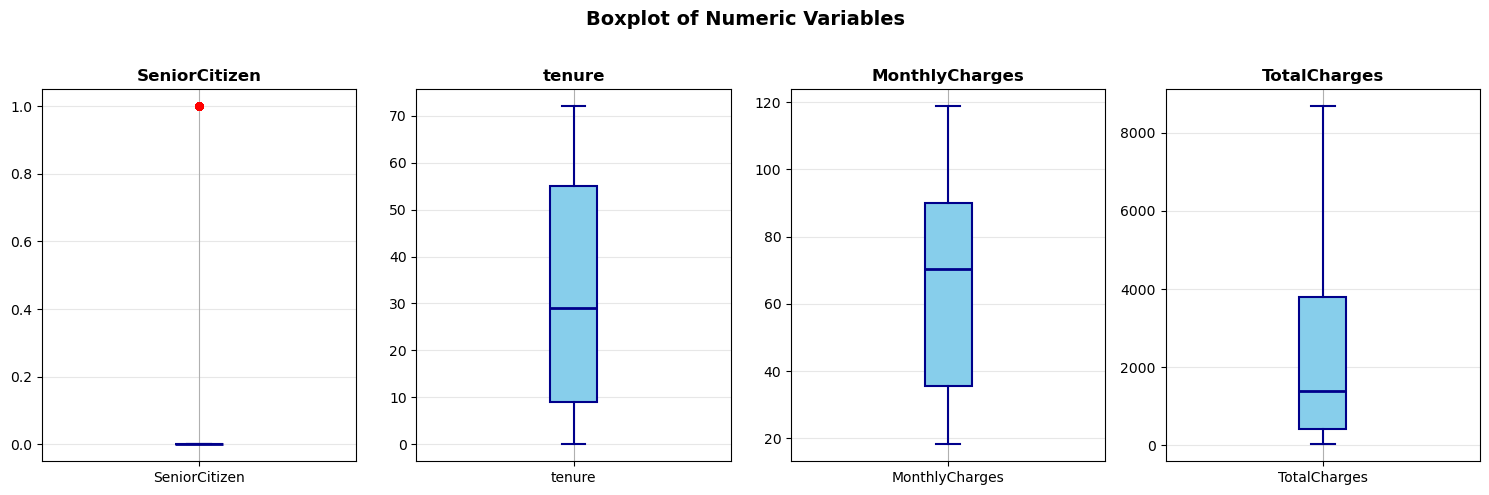

In [10]:
# 수치형 컬럼만 선택
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("======================== 이상치 분석 (IQR) ========================")

outliers_info = []

for col in numeric_cols:
    # IQR 계산
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 범위 계산 (1.5 * IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 개수 계산
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100
    
    outliers_info.append({
        '컬럼': col,
        '이상치_개수': outlier_count,
        '이상치_비율(%)': round(outlier_pct, 2),
        '하한선': round(lower_bound, 2),
        '상한선': round(upper_bound, 2)
    })

outliers_df = pd.DataFrame(outliers_info)
print(outliers_df)
print("=================================================================")

# 시각화: Box Plot으로 이상치 확인
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))

for idx, col in enumerate(numeric_cols):
    ax = axes[idx] if len(numeric_cols) > 1 else axes
    bp = df.boxplot(column=col, ax=ax, patch_artist=True, return_type='dict')
    
    # 박스 색상을 파란색으로 변경
    for box in bp['boxes']:
        box.set_facecolor('skyblue')
        box.set_edgecolor('darkblue')
        box.set_linewidth(1.5)
    
    # 중앙선을 진한 파란색으로
    for median in bp['medians']:
        median.set_color('darkblue')
        median.set_linewidth(2)
    
    # 수염(whiskers)을 파란색으로
    for whisker in bp['whiskers']:
        whisker.set_color('darkblue')
        whisker.set_linewidth(1.5)
    
    # 캡(caps)을 파란색으로
    for cap in bp['caps']:
        cap.set_color('darkblue')
        cap.set_linewidth(1.5)
    
    # 이상치는 빨간색 점으로 표시
    for flier in bp['fliers']:
        flier.set_markeredgecolor('red')
        flier.set_markerfacecolor('red')
        flier.set_marker('o')
        flier.set_markersize(5)
    
    ax.set_title(f'{col}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Boxplot of Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [11]:
# SeniorCitizen 컬렴 형변환(수치형 -> 범주형)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'Not Senior', 1: 'Senior'})
print(df['SeniorCitizen'].dtype)

object


In [12]:
#df.info()

### 2-3. Unique 값과 빈도 분석



In [13]:
# 범주형 컬럼 선택 (customerID 제외)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')

print("=" * 80)
print("Unique Values and Frequency of Categorical Variables".center(80))
print("=" * 80)

unique_info = []

for col in categorical_cols:
    unique_count = df[col].nunique()
    most_common = df[col].value_counts().head(1)
    
    unique_info.append({
        '컬럼': col,
        'Unique_개수': unique_count,
        '최빈값': most_common.index[0],
        '최빈값_빈도': most_common.values[0],
        '최빈값_비율(%)': round((most_common.values[0] / len(df)) * 100, 2)
    })

unique_df = pd.DataFrame(unique_info)
print(unique_df)



              Unique Values and Frequency of Categorical Variables              
                  컬럼  Unique_개수               최빈값  최빈값_빈도  최빈값_비율(%)
0             gender          2              Male    3555      50.48
1      SeniorCitizen          2        Not Senior    5901      83.79
2            Partner          2                No    3641      51.70
3         Dependents          2                No    4933      70.04
4       PhoneService          2               Yes    6361      90.32
5      MultipleLines          3                No    3390      48.13
6    InternetService          3       Fiber optic    3096      43.96
7     OnlineSecurity          3                No    3498      49.67
8       OnlineBackup          3                No    3088      43.84
9   DeviceProtection          3                No    3095      43.94
10       TechSupport          3                No    3473      49.31
11       StreamingTV          3                No    2810      39.90
12   StreamingMovies  

### 2-4. 기술통계 분석


In [14]:
# 기본 기술통계
print("============================== 수치형 변수 기술통계 ==============================\n")
print(df.describe().T)

# 추가 통계량 (중앙값, 최빈값, 왜도, 첨도)
print("\n\n======================= 추가 통계량 ========================\n")

advanced_stats = []

# 수치형 컬럼 재정의 (SeniorCitizen이 object로 변환되었으므로)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    stats_dict = {
        '컬럼': col,
        '중앙값': round(df[col].median(), 2),
        '왜도(Skewness)': round(df[col].skew(), 2),
        '첨도(Kurtosis)': round(df[col].kurtosis(), 2)
    }
    advanced_stats.append(stats_dict)

stats_df = pd.DataFrame(advanced_stats)
print(stats_df.to_string(index=False))


============================== 수치형 변수 기술통계 ==============================

                 count         mean          std    min     25%       50%  \
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.000   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.350   
TotalCharges    7032.0  2283.300441  2266.771362  18.80  401.45  1397.475   

                      75%      max  
tenure            55.0000    72.00  
MonthlyCharges    89.8500   118.75  
TotalCharges    3794.7375  8684.80  


======================= 추가 통계량 ========================

            컬럼     중앙값  왜도(Skewness)  첨도(Kurtosis)
        tenure   29.00          0.24         -1.39
MonthlyCharges   70.35         -0.22         -1.26
  TotalCharges 1397.47          0.96         -0.23


### 2-5. 상관관계 분석


========================== 상관관계 매트릭스 ===========================

                  tenure  MonthlyCharges  TotalCharges     Churn
tenure          1.000000        0.247900      0.825880 -0.352229
MonthlyCharges  0.247900        1.000000      0.651065  0.193356
TotalCharges    0.825880        0.651065      1.000000 -0.199484
Churn          -0.352229        0.193356     -0.199484  1.000000


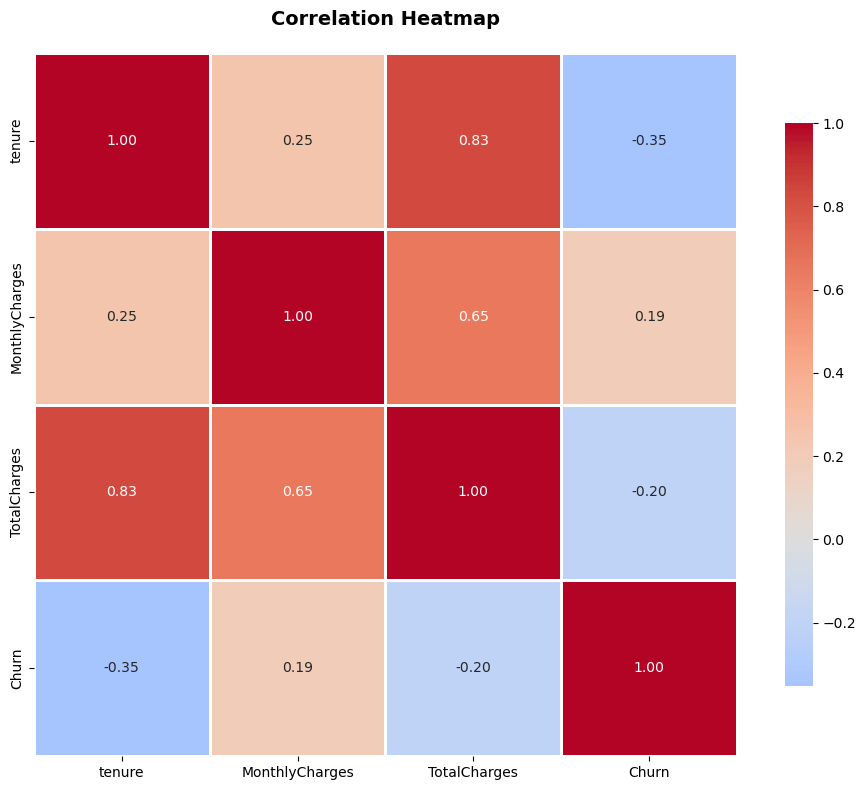

In [15]:
# Churn을 숫자로 변환 (상관관계 계산을 위해)
df_temp = df.copy()
df_temp['Churn'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})

# 수치형 컬럼 + Churn_binary
correlation_cols = numeric_cols + ['Churn']
correlation_matrix = df_temp[correlation_cols].corr()

print("========================== 상관관계 매트릭스 ===========================\n")
print(correlation_matrix)

# 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


Churn과의 상관관계:
- tenure: -0.35 (음의 상관) → 오래 가입할수록 이탈 낮음
- MonthlyCharges: 0.19 (양의 상관) → 요금 높을수록 이탈 높음
- TotalCharges: -0.20 (음의 상관) → 총액 높을수록 이탈 낮음

### 2-6. Information Value (IV) 분석

=== Information Value (변수 중요도) ===



/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_62994/2017826796.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby(feature_col)[target].agg(['sum', 'count'])
/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_62994/2017826796.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby(feature_col)[target].agg(['sum', 'count'])
/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_62994/2017826796.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False

                  변수      IV   타입
16          Contract  1.2386  범주형
0             tenure  0.8237  수치형
10    OnlineSecurity  0.7178  범주형
13       TechSupport  0.6996  범주형
9    InternetService  0.6180  범주형
11      OnlineBackup  0.5286  범주형
12  DeviceProtection  0.4997  범주형
18     PaymentMethod  0.4571  범주형
15   StreamingMovies  0.3814  범주형
14       StreamingTV  0.3805  범주형
1     MonthlyCharges  0.3647  수치형
2       TotalCharges  0.3376  수치형
17  PaperlessBilling  0.2031  범주형
6         Dependents  0.1555  범주형
5            Partner  0.1187  범주형
4      SeniorCitizen  0.1056  범주형
8      MultipleLines  0.0082  범주형
7       PhoneService  0.0007  범주형
3             gender  0.0004  범주형


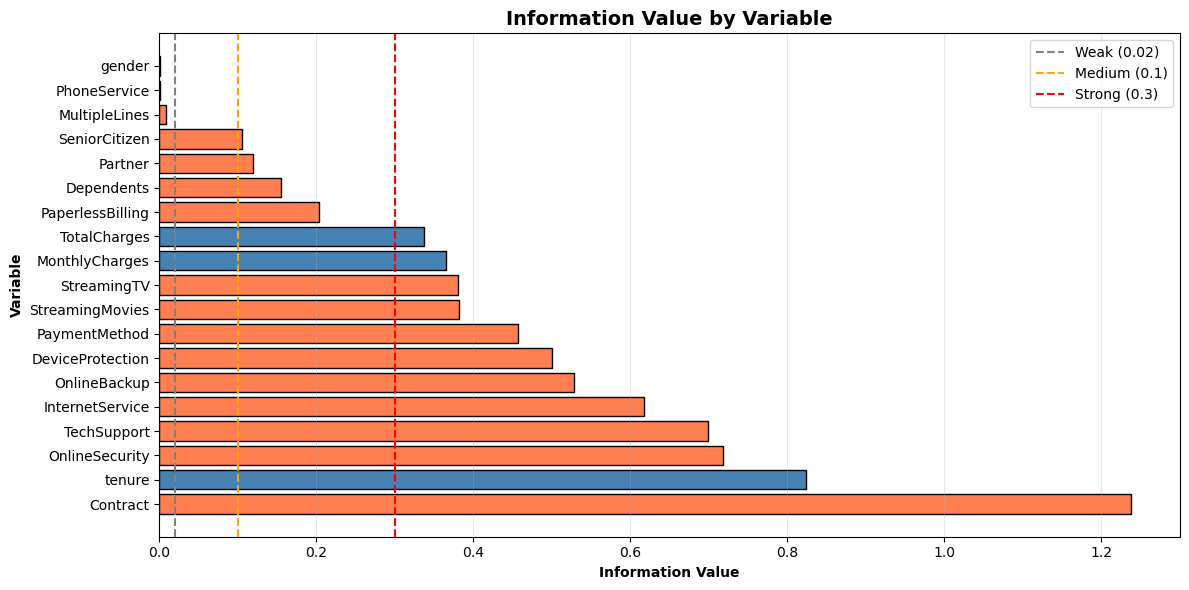

In [16]:
# Information Value 계산 함수
def calculate_iv(df, feature, target):
    # 타겟이 문자열이면 숫자로 변환
    df_temp = df.copy()
    if df_temp[target].dtype == 'object':
        df_temp[target] = df_temp[target].map({'Yes': 1, 'No': 0})
    
    # 수치형 변수는 구간으로 나누기 (binning)
    if df_temp[feature].dtype in ['int64', 'float64']:
        # 결측치가 있으면 제거
        df_temp = df_temp[[feature, target]].dropna()
        # 10개 구간으로 나누기
        df_temp[feature + '_bin'] = pd.qcut(df_temp[feature], q=10, duplicates='drop')
        feature_col = feature + '_bin'
    else:
        feature_col = feature
    
    # 각 범주별 Good(0)과 Bad(1) 개수 계산
    grouped = df_temp.groupby(feature_col)[target].agg(['sum', 'count'])
    grouped.columns = ['Bad', 'Total']
    grouped['Good'] = grouped['Total'] - grouped['Bad']
    
    # 전체 Good, Bad 개수
    total_good = grouped['Good'].sum()
    total_bad = grouped['Bad'].sum()
    
    # WOE와 IV 계산
    grouped['Good_pct'] = grouped['Good'] / total_good
    grouped['Bad_pct'] = grouped['Bad'] / total_bad
    
    # 0 방지 (작은 값 추가)
    grouped['Good_pct'] = grouped['Good_pct'].replace(0, 0.0001)
    grouped['Bad_pct'] = grouped['Bad_pct'].replace(0, 0.0001)
    
    # WOE = ln(Good% / Bad%)
    grouped['WOE'] = np.log(grouped['Good_pct'] / grouped['Bad_pct'])
    
    # IV = (Good% - Bad%) * WOE
    grouped['IV'] = (grouped['Good_pct'] - grouped['Bad_pct']) * grouped['WOE']
    
    iv_total = grouped['IV'].sum()
    
    return iv_total

# 모든 변수에 대해 IV 계산
print("=== Information Value (변수 중요도) ===\n")

iv_results = []

# 수치형 변수
for col in numeric_cols:
    try:
        iv = calculate_iv(df, col, 'Churn')
        iv_results.append({'변수': col, 'IV': round(iv, 4), '타입': '수치형'})
    except:
        pass

# 범주형 변수 (customerID 제외)
for col in categorical_cols:
    try:
        iv = calculate_iv(df, col, 'Churn')
        iv_results.append({'변수': col, 'IV': round(iv, 4), '타입': '범주형'})
    except:
        pass

# 결과 정리
iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False)
print(iv_df)

# 시각화
plt.figure(figsize=(12, 6))
colors = ['steelblue' if x == '수치형' else 'coral' for x in iv_df['타입']]
plt.barh(iv_df['변수'], iv_df['IV'], color=colors, edgecolor='black')
plt.xlabel('Information Value', fontweight='bold')
plt.ylabel('Variable', fontweight='bold')
plt.title('Information Value by Variable', fontsize=14, fontweight='bold')
plt.axvline(x=0.02, color='gray', linestyle='--', label='Weak (0.02)')
plt.axvline(x=0.1, color='orange', linestyle='--', label='Medium (0.1)')
plt.axvline(x=0.3, color='red', linestyle='--', label='Strong (0.3)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### 2-7. 분포 시각화 (히스토그램, 막대그래프, 박스플롯)


In [17]:
def plot_target_eda_universal(data, column_name, target_col='Churn', bins=10, 
                             method='quantile', figsize=(6, 4)):
    """
    수치형/범주형 변수 모두 지원하는 통합 Target EDA 함수
    
    Parameters:
    -----------
    data : DataFrame
        분석할 데이터프레임
    column_name : str
        분석할 컬럼명 (수치형 또는 범주형)
    target_col : str
        타겟 변수 컬럼명 (기본값: 'Churn')
    bins : int, optional
        수치형일 때 구간 개수 (기본값: 10)
    method : str, optional
        수치형 구간 나누기 방법 ('quantile': 분위수, 'uniform': 등간격) (기본값: 'quantile')
    figsize : tuple, optional
        그래프 크기 (기본값: (6, 4))
    
    Returns:
    --------
    DataFrame: 구간별 통계 결과
    """
    
    # 1. 데이터 유효성 검사
    if column_name not in data.columns:
        raise ValueError(f"컬럼 '{column_name}'이 데이터에 존재하지 않습니다.")
    
    if target_col not in data.columns:
        raise ValueError(f"타겟 컬럼 '{target_col}'이 데이터에 존재하지 않습니다.")
    
    # 2. 데이터 타입 확인
    is_numeric = pd.api.types.is_numeric_dtype(data[column_name])
    is_categorical = data[column_name].dtype == 'object' or data[column_name].dtype.name == 'category'
    
    print(f"📊 분석 대상: {column_name}")
    print(f"📋 데이터 타입: {'수치형' if is_numeric else '범주형'}")
    
    # 3. 데이터 준비
    df_temp = data[[column_name, target_col]].copy()
    
    # 타겟 변수 변환
    df_temp[target_col] = df_temp[target_col].map({'Yes': 1, 'No': 0})
    
    # 4. 구간/그룹 생성
    if is_numeric:
        # 수치형: binning 적용
        try:
            if method == 'quantile':
                df_temp[f'{column_name}_bin'] = pd.qcut(df_temp[column_name], q=bins, duplicates='drop')
                print(f"📊 분위수 기반 {len(df_temp[f'{column_name}_bin'].cat.categories)}개 구간 생성")
            elif method == 'uniform':
                df_temp[f'{column_name}_bin'] = pd.cut(df_temp[column_name], bins=bins, include_lowest=True)
                print(f"📊 등간격 기반 {len(df_temp[f'{column_name}_bin'].cat.categories)}개 구간 생성")
            else:
                raise ValueError("method는 'quantile' 또는 'uniform'이어야 합니다.")
        except Exception as e:
            print(f"⚠️ 구간 나누기 실패: {e}")
            print("등간격 구간으로 재시도합니다.")
            df_temp[f'{column_name}_bin'] = pd.cut(df_temp[column_name], bins=bins, include_lowest=True)
        
        group_col = f'{column_name}_bin'
        
    else:
        # 범주형: 그대로 사용 (binning 불필요)
        group_col = column_name
        unique_categories = df_temp[column_name].nunique()
        print(f"📊 범주형 데이터: {unique_categories}개 카테고리")
    
    # 5. 구간별 통계 계산
    bin_stats = df_temp.groupby(group_col).agg({
        column_name: ['count'],
        target_col: ['sum', 'count', 'mean']
    }).round(2)
    
    # 컬럼명 정리
    bin_stats.columns = ['count', 'target_sum', 'total_count', 'target_rate']
    bin_stats['composition_pct'] = (bin_stats['count'] / len(df_temp) * 100).round(2)
    bin_stats['target_rate_pct'] = (bin_stats['target_rate'] * 100).round(2)
    
    # 6. 그래프 그리기
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # X축 라벨 생성
    x_labels = []
    for idx in bin_stats.index:
        if is_numeric:
            x_labels.append(f"{idx.right:.1f}")
        else:
            # 범주형: 카테고리명 그대로 사용
            label = str(idx)
            x_labels.append(label)
    
    x_pos = range(len(x_labels))
    
    # 왼쪽 Y축: 구성비율 (막대그래프)
    bars = ax1.bar(x_pos, bin_stats['composition_pct'], 
                   alpha=0.7, color='lightblue', 
                   label='Composition (%)', edgecolor='black')
    ax1.set_xlabel(f'{column_name} {"Bins" if is_numeric else "Categories"}', fontweight='bold')
    ax1.set_ylabel('Composition (%)', fontweight='bold', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_ylim(0, max(bin_stats['composition_pct']) * 1.1)
    
    # 오른쪽 Y축: 타겟 비율 (꺾은선 그래프)
    ax2 = ax1.twinx()
    line = ax2.plot(x_pos, bin_stats['target_rate_pct'], 
                    color='red', marker='o', linewidth=2, markersize=6,
                    label='Target Rate (%)')
    ax2.set_ylabel('Target Rate (%)', fontweight='bold', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 100)
    
    # X축 설정
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(x_labels, rotation=45, ha='right')
    
    # 7. 제목과 범례
    total_samples = len(df_temp)
    avg_target_rate = df_temp[target_col].mean() * 100
    
    plt.title(f'Target EDA - {column_name}', 
              fontsize=12, fontweight='bold', pad=20)
    
    # 범례 합치기
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    # 격자 추가
    ax1.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 8. 구간별 분석 출력
    print(f"\n{'='*60}")
    print(f"📊 {column_name} 구간별 분석 결과 ({'수치형' if is_numeric else '범주형'})")
    print(f"{'='*60}")
    print(f"📈 총 샘플 수: {total_samples:,}개")
    print(f"📊 총 {'구간' if is_numeric else '카테고리'} 수: {len(bin_stats)}개")
    
    # 9. 인사이트 제공
    max_rate_idx = bin_stats['target_rate_pct'].idxmax()
    min_rate_idx = bin_stats['target_rate_pct'].idxmin()
    
    print(f"\n💡 주요 인사이트:")
    print(f"   • 이탈률이 가장 높은 {'구간' if is_numeric else '카테고리'}: {max_rate_idx} ({bin_stats.loc[max_rate_idx, 'target_rate_pct']:.1f}%)")
    print(f"   • 이탈률이 가장 낮은 {'구간' if is_numeric else '카테고리'}: {min_rate_idx} ({bin_stats.loc[min_rate_idx, 'target_rate_pct']:.1f}%)")
    
    # 타겟율 차이가 큰 경우 경고
    rate_diff = bin_stats['target_rate_pct'].max() - bin_stats['target_rate_pct'].min()
    if rate_diff > 20:
        print(f"   ⚠️ {'구간' if is_numeric else '카테고리'}별 이탈률 차이가 {rate_diff:.1f}%p로 매우 큼 - 강한 예측 변수!")
    
    return bin_stats



📊 분석 대상: tenure
📋 데이터 타입: 수치형
📊 분위수 기반 10개 구간 생성


/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_62994/2848070740.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_temp.groupby(group_col).agg({


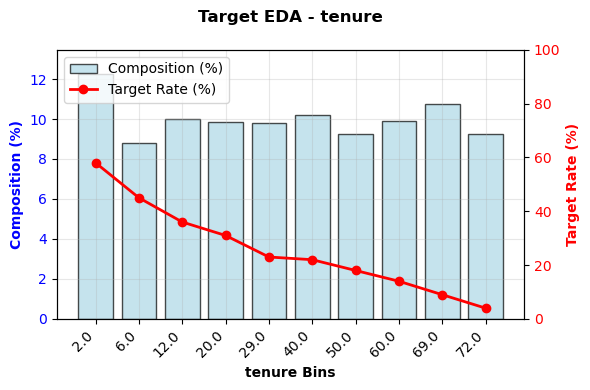


📊 tenure 구간별 분석 결과 (수치형)
📈 총 샘플 수: 7,043개
📊 총 구간 수: 10개

💡 주요 인사이트:
   • 이탈률이 가장 높은 구간: (-0.001, 2.0] (58.0%)
   • 이탈률이 가장 낮은 구간: (69.0, 72.0] (4.0%)
   ⚠️ 구간별 이탈률 차이가 54.0%p로 매우 큼 - 강한 예측 변수!


,count,target_sum,total_count,target_rate,composition_pct,target_rate_pct
tenure_bin,,,,,,
"(-0.001, 2.0]",862,503,862,0.58,12.24,58.0
"(2.0, 6.0]",619,281,619,0.45,8.79,45.0
"(6.0, 12.0]",705,253,705,0.36,10.01,36.0
"(12.0, 20.0]",692,214,692,0.31,9.83,31.0
"(20.0, 29.0]",691,158,691,0.23,9.81,23.0
"(29.0, 40.0]",717,157,717,0.22,10.18,22.0
"(40.0, 50.0]",652,115,652,0.18,9.26,18.0
"(50.0, 60.0]",698,95,698,0.14,9.91,14.0
"(60.0, 69.0]",756,70,756,0.09,10.73,9.0


In [18]:
plot_target_eda_universal(df, 'tenure')

📊 분석 대상: MonthlyCharges
📋 데이터 타입: 수치형
📊 분위수 기반 10개 구간 생성


/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_62994/2848070740.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_temp.groupby(group_col).agg({


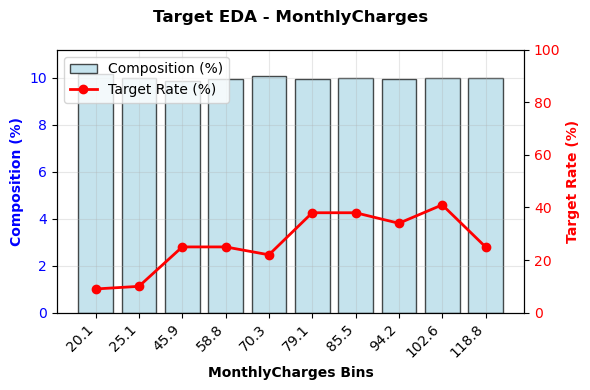


📊 MonthlyCharges 구간별 분석 결과 (수치형)
📈 총 샘플 수: 7,043개
📊 총 구간 수: 10개

💡 주요 인사이트:
   • 이탈률이 가장 높은 구간: (94.25, 102.6] (41.0%)
   • 이탈률이 가장 낮은 구간: (18.249, 20.05] (9.0%)
   ⚠️ 구간별 이탈률 차이가 32.0%p로 매우 큼 - 강한 예측 변수!


,count,target_sum,total_count,target_rate,composition_pct,target_rate_pct
MonthlyCharges_bin,,,,,,
"(18.249, 20.05]",717,61,717,0.09,10.18,9.0
"(20.05, 25.05]",703,69,703,0.10,9.98,10.0
"(25.05, 45.85]",695,177,695,0.25,9.87,25.0
"(45.85, 58.83]",702,172,702,0.25,9.97,25.0
"(58.83, 70.35]",711,153,711,0.22,10.10,22.0
"(70.35, 79.1]",700,267,700,0.38,9.94,38.0
"(79.1, 85.5]",705,267,705,0.38,10.01,38.0
"(85.5, 94.25]",702,241,702,0.34,9.97,34.0
"(94.25, 102.6]",704,288,704,0.41,10.00,41.0


In [19]:
plot_target_eda_universal(df, 'MonthlyCharges')

📊 분석 대상: TotalCharges
📋 데이터 타입: 수치형
📊 분위수 기반 10개 구간 생성


/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_62994/2848070740.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_temp.groupby(group_col).agg({


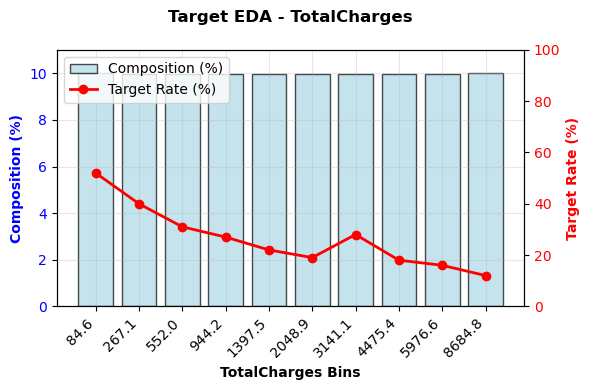


📊 TotalCharges 구간별 분석 결과 (수치형)
📈 총 샘플 수: 7,043개
📊 총 구간 수: 10개

💡 주요 인사이트:
   • 이탈률이 가장 높은 구간: (18.799, 84.6] (52.0%)
   • 이탈률이 가장 낮은 구간: (5976.64, 8684.8] (12.0%)
   ⚠️ 구간별 이탈률 차이가 40.0%p로 매우 큼 - 강한 예측 변수!


,count,target_sum,total_count,target_rate,composition_pct,target_rate_pct
TotalCharges_bin,,,,,,
"(18.799, 84.6]",705,369,705,0.52,10.01,52.0
"(84.6, 267.07]",702,278,702,0.40,9.97,40.0
"(267.07, 551.995]",703,215,703,0.31,9.98,31.0
"(551.995, 944.17]",703,192,703,0.27,9.98,27.0
"(944.17, 1397.475]",703,155,703,0.22,9.98,22.0
"(1397.475, 2048.95]",703,137,703,0.19,9.98,19.0
"(2048.95, 3141.13]",703,198,703,0.28,9.98,28.0
"(3141.13, 4475.41]",703,126,703,0.18,9.98,18.0
"(4475.41, 5976.64]",703,111,703,0.16,9.98,16.0


In [20]:
plot_target_eda_universal(df, 'TotalCharges')

📊 분석 대상: Contract
📋 데이터 타입: 범주형
📊 범주형 데이터: 3개 카테고리


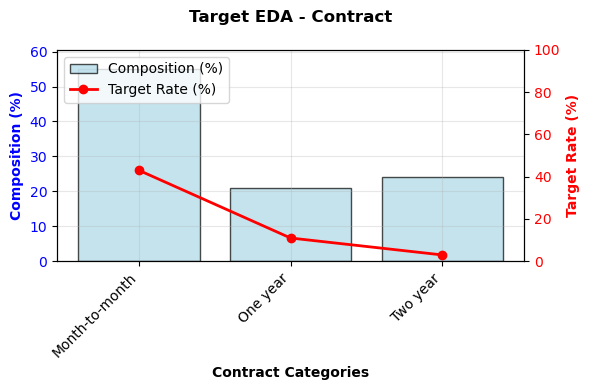


📊 Contract 구간별 분석 결과 (범주형)
📈 총 샘플 수: 7,043개
📊 총 카테고리 수: 3개

💡 주요 인사이트:
   • 이탈률이 가장 높은 카테고리: Month-to-month (43.0%)
   • 이탈률이 가장 낮은 카테고리: Two year (3.0%)
   ⚠️ 카테고리별 이탈률 차이가 40.0%p로 매우 큼 - 강한 예측 변수!


,count,target_sum,total_count,target_rate,composition_pct,target_rate_pct
Contract,,,,,,
Month-to-month,3875,1655,3875,0.43,55.02,43.0
One year,1473,166,1473,0.11,20.91,11.0
Two year,1695,48,1695,0.03,24.07,3.0


In [21]:
plot_target_eda_universal(df, 'Contract')

📊 분석 대상: OnlineSecurity
📋 데이터 타입: 범주형
📊 범주형 데이터: 3개 카테고리


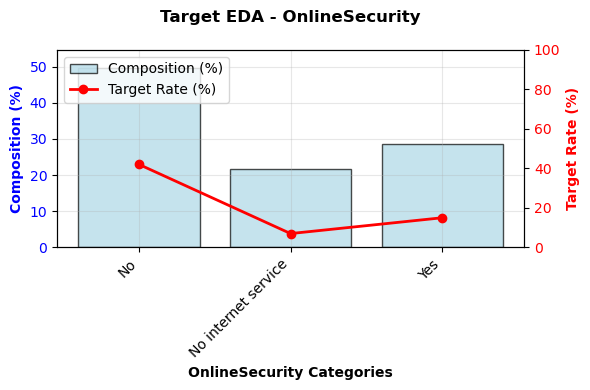


📊 OnlineSecurity 구간별 분석 결과 (범주형)
📈 총 샘플 수: 7,043개
📊 총 카테고리 수: 3개

💡 주요 인사이트:
   • 이탈률이 가장 높은 카테고리: No (42.0%)
   • 이탈률이 가장 낮은 카테고리: No internet service (7.0%)
   ⚠️ 카테고리별 이탈률 차이가 35.0%p로 매우 큼 - 강한 예측 변수!


,count,target_sum,total_count,target_rate,composition_pct,target_rate_pct
OnlineSecurity,,,,,,
No,3498,1461,3498,0.42,49.67,42.0
No internet service,1526,113,1526,0.07,21.67,7.0
Yes,2019,295,2019,0.15,28.67,15.0


In [22]:
plot_target_eda_universal(df, 'OnlineSecurity')

📊 분석 대상: TechSupport
📋 데이터 타입: 범주형
📊 범주형 데이터: 3개 카테고리


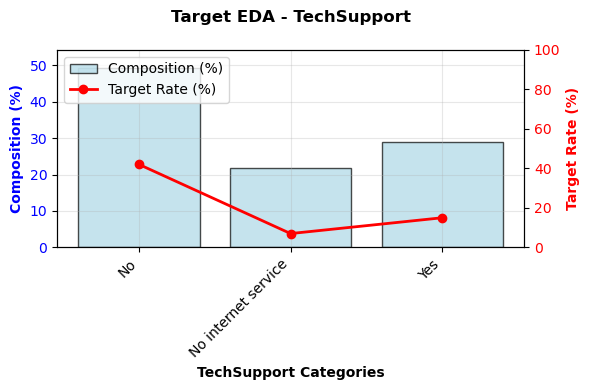


📊 TechSupport 구간별 분석 결과 (범주형)
📈 총 샘플 수: 7,043개
📊 총 카테고리 수: 3개

💡 주요 인사이트:
   • 이탈률이 가장 높은 카테고리: No (42.0%)
   • 이탈률이 가장 낮은 카테고리: No internet service (7.0%)
   ⚠️ 카테고리별 이탈률 차이가 35.0%p로 매우 큼 - 강한 예측 변수!


,count,target_sum,total_count,target_rate,composition_pct,target_rate_pct
TechSupport,,,,,,
No,3473,1446,3473,0.42,49.31,42.0
No internet service,1526,113,1526,0.07,21.67,7.0
Yes,2044,310,2044,0.15,29.02,15.0


In [23]:
plot_target_eda_universal(df, 'TechSupport')

📊 분석 대상: InternetService
📋 데이터 타입: 범주형
📊 범주형 데이터: 3개 카테고리


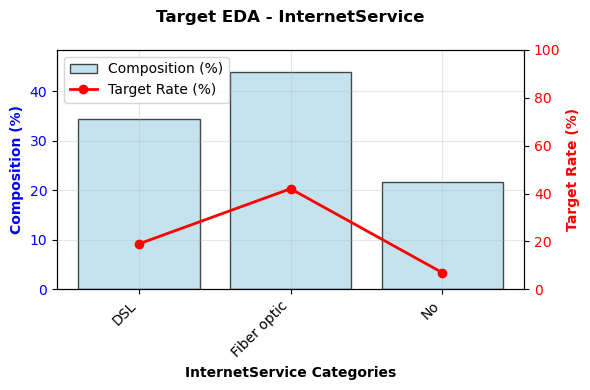


📊 InternetService 구간별 분석 결과 (범주형)
📈 총 샘플 수: 7,043개
📊 총 카테고리 수: 3개

💡 주요 인사이트:
   • 이탈률이 가장 높은 카테고리: Fiber optic (42.0%)
   • 이탈률이 가장 낮은 카테고리: No (7.0%)
   ⚠️ 카테고리별 이탈률 차이가 35.0%p로 매우 큼 - 강한 예측 변수!


,count,target_sum,total_count,target_rate,composition_pct,target_rate_pct
InternetService,,,,,,
DSL,2421,459,2421,0.19,34.37,19.0
Fiber optic,3096,1297,3096,0.42,43.96,42.0
No,1526,113,1526,0.07,21.67,7.0


In [24]:
plot_target_eda_universal(df, 'InternetService')

📊 분석 대상: OnlineBackup
📋 데이터 타입: 범주형
📊 범주형 데이터: 3개 카테고리


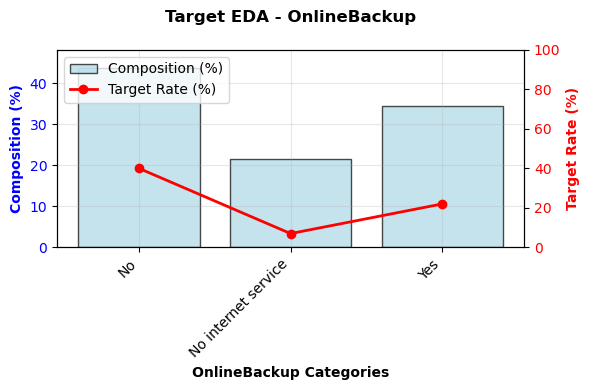


📊 OnlineBackup 구간별 분석 결과 (범주형)
📈 총 샘플 수: 7,043개
📊 총 카테고리 수: 3개

💡 주요 인사이트:
   • 이탈률이 가장 높은 카테고리: No (40.0%)
   • 이탈률이 가장 낮은 카테고리: No internet service (7.0%)
   ⚠️ 카테고리별 이탈률 차이가 33.0%p로 매우 큼 - 강한 예측 변수!


,count,target_sum,total_count,target_rate,composition_pct,target_rate_pct
OnlineBackup,,,,,,
No,3088,1233,3088,0.40,43.84,40.0
No internet service,1526,113,1526,0.07,21.67,7.0
Yes,2429,523,2429,0.22,34.49,22.0


In [25]:
plot_target_eda_universal(df, 'OnlineBackup')

📊 분석 대상: DeviceProtection
📋 데이터 타입: 범주형
📊 범주형 데이터: 3개 카테고리


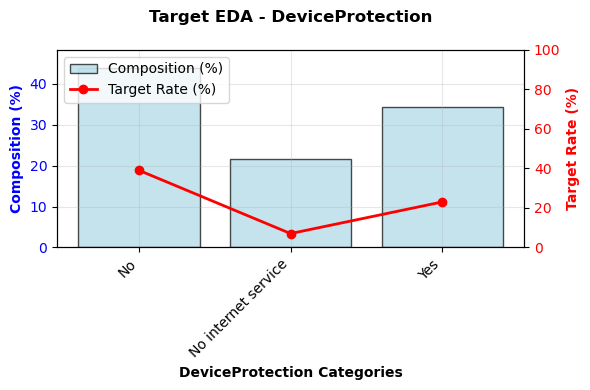


📊 DeviceProtection 구간별 분석 결과 (범주형)
📈 총 샘플 수: 7,043개
📊 총 카테고리 수: 3개

💡 주요 인사이트:
   • 이탈률이 가장 높은 카테고리: No (39.0%)
   • 이탈률이 가장 낮은 카테고리: No internet service (7.0%)
   ⚠️ 카테고리별 이탈률 차이가 32.0%p로 매우 큼 - 강한 예측 변수!


,count,target_sum,total_count,target_rate,composition_pct,target_rate_pct
DeviceProtection,,,,,,
No,3095,1211,3095,0.39,43.94,39.0
No internet service,1526,113,1526,0.07,21.67,7.0
Yes,2422,545,2422,0.23,34.39,23.0


In [26]:
plot_target_eda_universal(df, 'DeviceProtection')

📊 분석 대상: PaymentMethod
📋 데이터 타입: 범주형
📊 범주형 데이터: 4개 카테고리


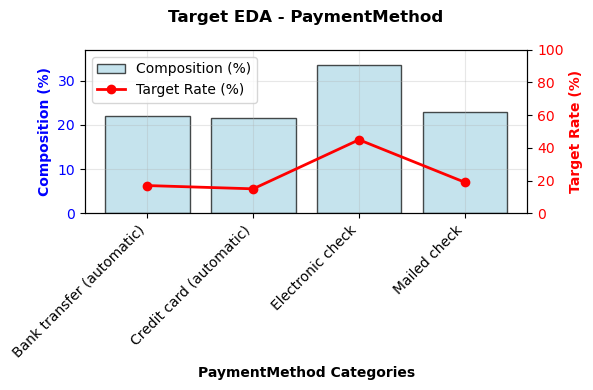


📊 PaymentMethod 구간별 분석 결과 (범주형)
📈 총 샘플 수: 7,043개
📊 총 카테고리 수: 4개

💡 주요 인사이트:
   • 이탈률이 가장 높은 카테고리: Electronic check (45.0%)
   • 이탈률이 가장 낮은 카테고리: Credit card (automatic) (15.0%)
   ⚠️ 카테고리별 이탈률 차이가 30.0%p로 매우 큼 - 강한 예측 변수!


,count,target_sum,total_count,target_rate,composition_pct,target_rate_pct
PaymentMethod,,,,,,
Bank transfer (automatic),1544,258,1544,0.17,21.92,17.0
Credit card (automatic),1522,232,1522,0.15,21.61,15.0
Electronic check,2365,1071,2365,0.45,33.58,45.0
Mailed check,1612,308,1612,0.19,22.89,19.0


In [27]:
plot_target_eda_universal(df, 'PaymentMethod')

## 3.데이터 전처리

### 3-1. 결측치 처리

In [28]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [29]:
# 결측치 데이터 확인
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,Not Senior,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,Not Senior,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,Not Senior,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,Not Senior,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,Not Senior,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,Not Senior,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,Not Senior,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,Not Senior,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,Not Senior,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,Not Senior,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [30]:
# TotalCharges의 결측치는 신규가입 고객 -> 결측치 0으로 처리
df['TotalCharges'] = df['TotalCharges'].replace(np.nan, 0)

In [31]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 3-2. 이상치 처리

- Telco 데이터에는 실제 이상치가 없으므로 처리가 불필요
- 하지만 선택에 따라 제거, 로그 변환, 구간화 등의 방법을 시도해볼 수 있음


### 3-3. 문자형 데이터 라벨인코딩

In [32]:
df_processed = df.copy()
df_processed = df_processed.drop('customerID', axis=1)

y = df_processed['Churn'].map({'Yes': 1, 'No': 0})
df_processed = df_processed.drop('Churn', axis=1)

categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()

df_encoded = df_processed.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    unique_values = df_processed[col].unique()[:3]
    encoded_values = le.fit(df_processed[col]).transform(unique_values)
    

df_encoded.dtypes.value_counts()

int64      17
float64     2
Name: count, dtype: int64

In [33]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


### 3-4. 수치형 데이터 스케일링

In [34]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

X = df_encoded
y = y


In [35]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,-1.277445,0,1,0,0,2,0,0,0,0,0,1,2,-1.160323,-0.992611
1,1,0,0,0,0.066327,1,0,0,2,0,2,0,0,0,1,0,3,-0.259629,-0.172165
2,1,0,0,0,-1.236724,1,0,0,2,2,0,0,0,0,0,1,3,-0.362660,-0.958066
3,1,0,0,0,0.514251,0,1,0,2,0,2,2,0,0,1,0,0,-0.746535,-0.193672
4,0,0,0,0,-1.236724,1,0,1,0,0,0,0,0,0,0,1,2,0.197365,-0.938874
